# Miniproject 1 – Architecture 1: Underfitting CNN

**Team Members:** Aurel Köppel, Yves Fricker

**Course:** Applications of AI (AiAp), OST, Spring 2026

---

This notebook trains a deliberately under-parameterised CNN on the Animals-10 dataset. The goal is to observe underfitting in a controlled setting and to establish a baseline before the larger architectures in notebooks 2 and 3.

## 1. Imports and Setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Set Keras backend to TensorFlow
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers

# Import our shared helper functions
from helpers import (
    load_animals10,
    split_data,
    plot_learning_curves,
    plot_confusion_matrices,
    print_classification_metrics,
)

print(f"Keras version: {keras.__version__}")
print(f"Backend: {keras.backend.backend()}")

Keras version: 3.13.2
Backend: tensorflow


## 2. Dataset: Animals-10

Source: [Animals-10 on Kaggle](https://www.kaggle.com/datasets/alessiocorrado99/animals10), author Alessio Corrado, GPL-2 licence.

The dataset contains images of 10 animal categories. The folder names are in Italian, so we map them to English for readability:

| Italian | English |
|---|---|
| cane | dog |
| cavallo | horse |
| elefante | elephant |
| farfalla | butterfly |
| gallina | chicken |
| gatto | cat |
| mucca | cow |
| pecora | sheep |
| ragno | spider |
| scoiattolo | squirrel |

### Preprocessing

We resize every image to 64×64 and divide by 255 so the pixel values land in [0, 1]. The per-class sample counts are capped at 1000, except for `elefante`, which we cut to 150 to create the class imbalance required by task c). After that, 30 % of the data goes into a locked test set and the remaining 70 % is used for training and validation.

In [2]:
import kagglehub

# Download dataset automatically (cached after first download)
path = kagglehub.dataset_download("alessiocorrado99/animals10")
DATA_DIR = os.path.join(path, "raw-img")

print(f"Dataset path: {DATA_DIR}")

# Load the dataset
X, y, class_names = load_animals10(
    data_dir=DATA_DIR,
    img_size=64,
    samples_per_class=1000,
    reduced_class="elefante",
    reduced_count=150,
    seed=42,
)

print(f"\nImage shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Classes: {class_names}")
print(f"Value range: [{X.min():.2f}, {X.max():.2f}]")

Dataset path: C:\Users\Aurel\.cache\kagglehub\datasets\alessiocorrado99\animals10\versions\2\raw-img
  Loaded 1000 images for class 'dog' (folder: cane)
  Loaded 1000 images for class 'horse' (folder: cavallo)
  Loaded 150 images for class 'elephant' (folder: elefante)
  Loaded 1000 images for class 'butterfly' (folder: farfalla)
  Loaded 1000 images for class 'chicken' (folder: gallina)
  Loaded 1000 images for class 'cat' (folder: gatto)
  Loaded 1000 images for class 'cow' (folder: mucca)
  Loaded 1000 images for class 'sheep' (folder: pecora)
  Loaded 1000 images for class 'spider' (folder: ragno)
  Loaded 1000 images for class 'squirrel' (folder: scoiattolo)

Total: 9150 images, 10 classes

Image shape: (9150, 64, 64, 3)
Labels shape: (9150,)
Classes: ['dog', 'horse', 'elephant', 'butterfly', 'chicken', 'cat', 'cow', 'sheep', 'spider', 'squirrel']
Value range: [0.00, 1.00]


## 3. Data Split

30 % of the data is set aside as a test set and is not touched again until the final evaluation in notebook 3. The remaining 70 % is used for training and validation. We use a stratified split, so every class is represented proportionally on both sides.

In [3]:
X_trainval, X_test, y_trainval, y_test = split_data(X, y, test_size=0.3, random_state=42)

print(f"\nTrain+Val shape: {X_trainval.shape}")
print(f"Test shape:      {X_test.shape}")

Train+Val: 6405 samples
Test:      2745 samples (locked away)

Train+Val shape: (6405, 64, 64, 3)
Test shape:      (2745, 64, 64, 3)


## 4. Exploratory Data Analysis

A quick look at the data before we start modelling: class counts, a few example images, and basic pixel statistics.

### 4.1 Class Distribution

The class counts confirm the intended imbalance: elephant has 150 samples, every other class has 1000.

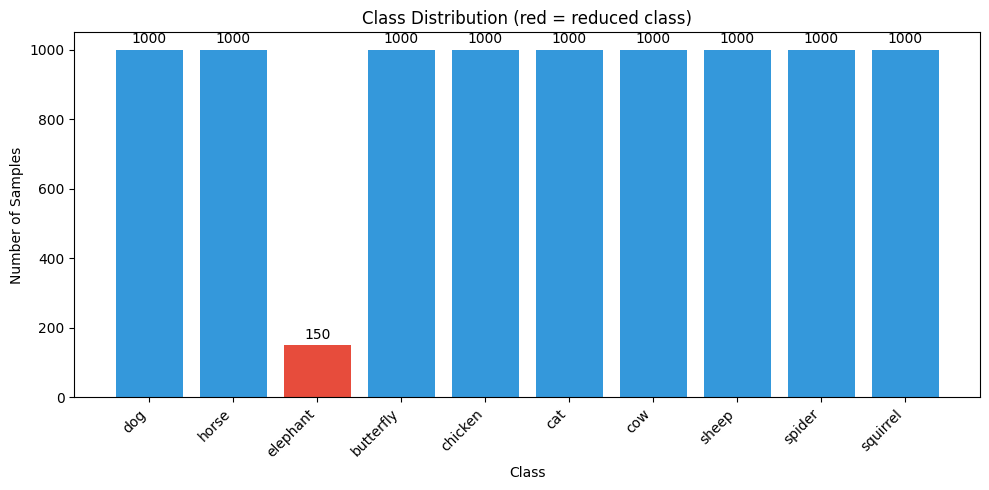

Dataset is IMBALANCED: 'elephant' has only 150 samples, all others have 1000.
Total samples: 9150


In [4]:
# Count samples per class
unique, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if class_names[i] == 'elephant' else '#3498db' for i in unique]
bars = plt.bar([class_names[i] for i in unique], counts, color=colors)
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution (red = reduced class)")
plt.xticks(rotation=45, ha="right")

# Add count labels on top of each bar
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
             str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Dataset is IMBALANCED: 'elephant' has only 150 samples, all others have 1000.")
print(f"Total samples: {len(y)}")

### 4.2 Sample Images

One example per class, to get a visual sense of intra-class variability (pose, background, lighting).

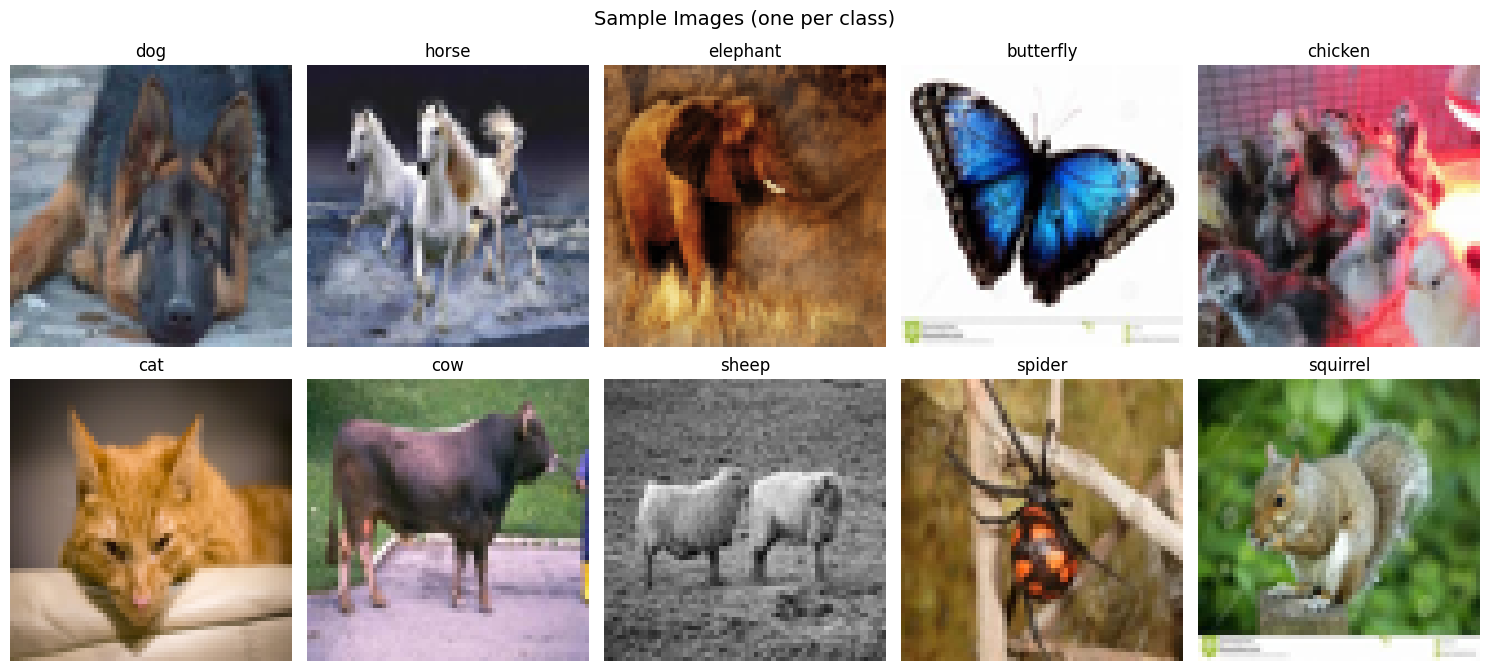

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle("Sample Images (one per class)", fontsize=14)

for idx, ax in enumerate(axes.flat):
    if idx < len(class_names):
        # Find first image of this class
        class_indices = np.where(y == idx)[0]
        sample_idx = class_indices[0]
        ax.imshow(X[sample_idx])
        ax.set_title(class_names[idx])
    ax.axis("off")

plt.tight_layout()
plt.show()

### 4.3 Image Statistics

A sanity check that pixel values are in the expected [0, 1] range after normalisation.

In [6]:
print(f"Image dtype:     {X.dtype}")
print(f"Image shape:     {X.shape[1:]} (height x width x channels)")
print(f"Pixel min value: {X.min():.4f}")
print(f"Pixel max value: {X.max():.4f}")
print(f"Pixel mean:      {X.mean():.4f}")
print(f"Pixel std:       {X.std():.4f}")
print(f"\n-> Values are in [0, 1] — normalization is correct.")

Image dtype:     float32
Image shape:     (64, 64, 3) (height x width x channels)
Pixel min value: 0.0000
Pixel max value: 1.0000
Pixel mean:      0.4702
Pixel std:       0.2648

-> Values are in [0, 1] — normalization is correct.


## 5. Model Definition

We keep the network intentionally tiny: three trainable layers, around 1700 parameters in total.

The architecture is two Conv2D blocks with 4 and 8 filters, each with `stride=2, padding="same"` followed by a `MaxPooling2D(2, 2)`. After the second pool, a `Flatten` feeds directly into `Dense(10, softmax)`. There is no intermediate dense layer.

With only 4 and 8 feature maps, the network can represent very few distinct patterns, roughly edges, colour blobs and basic textures. That is not enough to separate 10 animal classes, so we expect underfitting.

One implementation detail worth noting: we combine `stride=2` with max pooling to drop the spatial resolution quickly (64 → 32 → 16 → 8 → 4). We avoid `stride > kernel_size` because in that case the convolution kernel skips pixels entirely between filter positions, which means the filter does not slide continuously over the image and drops information between positions.

In [7]:
NUM_CLASSES = len(class_names)
IMG_SIZE = 64

model = keras.Sequential([
    # Input layer
    keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # First convolutional block: 4 filters, stride=2 to reduce dimensions quickly
    layers.Conv2D(4, (3, 3), strides=2, padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),  # 64 -> 32 (stride) -> 16 (pool)

    # Second convolutional block: 8 filters, stride=2
    layers.Conv2D(8, (3, 3), strides=2, padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),  # 16 -> 8 (stride) -> 4 (pool)

    # Flatten and classify
    layers.Flatten(),  # 4 * 4 * 8 = 128
    layers.Dense(NUM_CLASSES, activation="softmax"),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 4)           │             112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 4)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 8, 8, 8)             │             296 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 4, 4, 8)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,698 (6.63 KB)

 Trainable params: 1,698 (6.63 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Verify parameter count
total_params = model.count_params()
print(f"\nTotal trainable parameters: {total_params}")
print(f"Requirement: <= ~2000 parameters")
assert total_params <= 2000, f"Too many parameters: {total_params}"


Total trainable parameters: 1698
Requirement: <= ~2000 parameters


## 6. Compile and Train

Loss: `sparse_categorical_crossentropy` (integer labels, multi-class). Optimizer: Adam with default learning rate. Metric: accuracy.

We reserve 20 % of the train+val portion as a validation set inside `model.fit()`. Together with the 30 % test split, the effective split of the full dataset is roughly 56 % train, 14 % validation, 30 % test. We train for 50 epochs, which is more than enough for a 1.7k-parameter model to converge.

In [9]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    X_trainval,
    y_trainval,
    epochs=50,
    batch_size=32,
    validation_split=0.2,  # 20% of train+val data used for validation
    verbose=1,
)

Epoch 1/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1538 - loss: 2.2328 - val_accuracy: 0.2053 - val_loss: 2.1510
Epoch 2/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2143 - loss: 2.1132 - val_accuracy: 0.2334 - val_loss: 2.0808
Epoch 3/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2553 - loss: 2.0336 - val_accuracy: 0.2389 - val_loss: 2.0504
Epoch 4/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2750 - loss: 1.9903 - val_accuracy: 0.2600 - val_loss: 2.0103
Epoch 5/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2925 - loss: 1.9576 - val_accuracy: 0.2826 - val_loss: 1.9862
Epoch 6/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3048 - loss: 1.9347 - val_accuracy: 0.3084 - val_loss: 1.9522
Epoch 7/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3279 - loss: 1.9080 - val_accuracy: 0.3216 - val_loss: 1.9381
Epoch 8/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3327 - loss: 1.8827 - val_accuracy: 0.

## 7. Learning Curves

If the model is underfitting we expect both curves (train and validation) to converge towards similar, low values. The train-val gap stays small, but the overall accuracy also stays poor. That is the textbook signature of high bias.

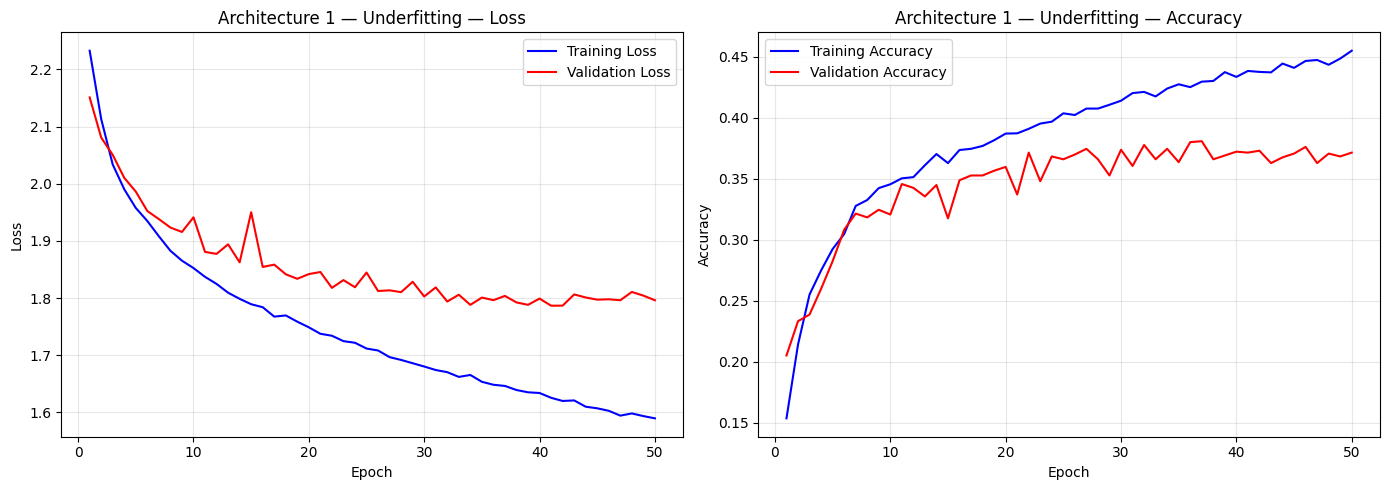

In [10]:
plot_learning_curves(history, title="Architecture 1 — Underfitting")

## 8. Confusion Matrices

We plot the validation confusion matrix four times with different normalisations:

1. Raw counts.
2. Row-normalised, which corresponds to recall per true class.
3. Column-normalised, which corresponds to precision per predicted class.
4. Normalised by the total number of samples.

In [11]:
# Split train+val data the same way Keras does with validation_split=0.2
# Keras takes the LAST 20% as validation
val_split = int(len(X_trainval) * 0.8)
X_val = X_trainval[val_split:]
y_val = y_trainval[val_split:]

# Get predictions
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

print(f"Validation set size: {len(X_val)}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Validation set size: 1281


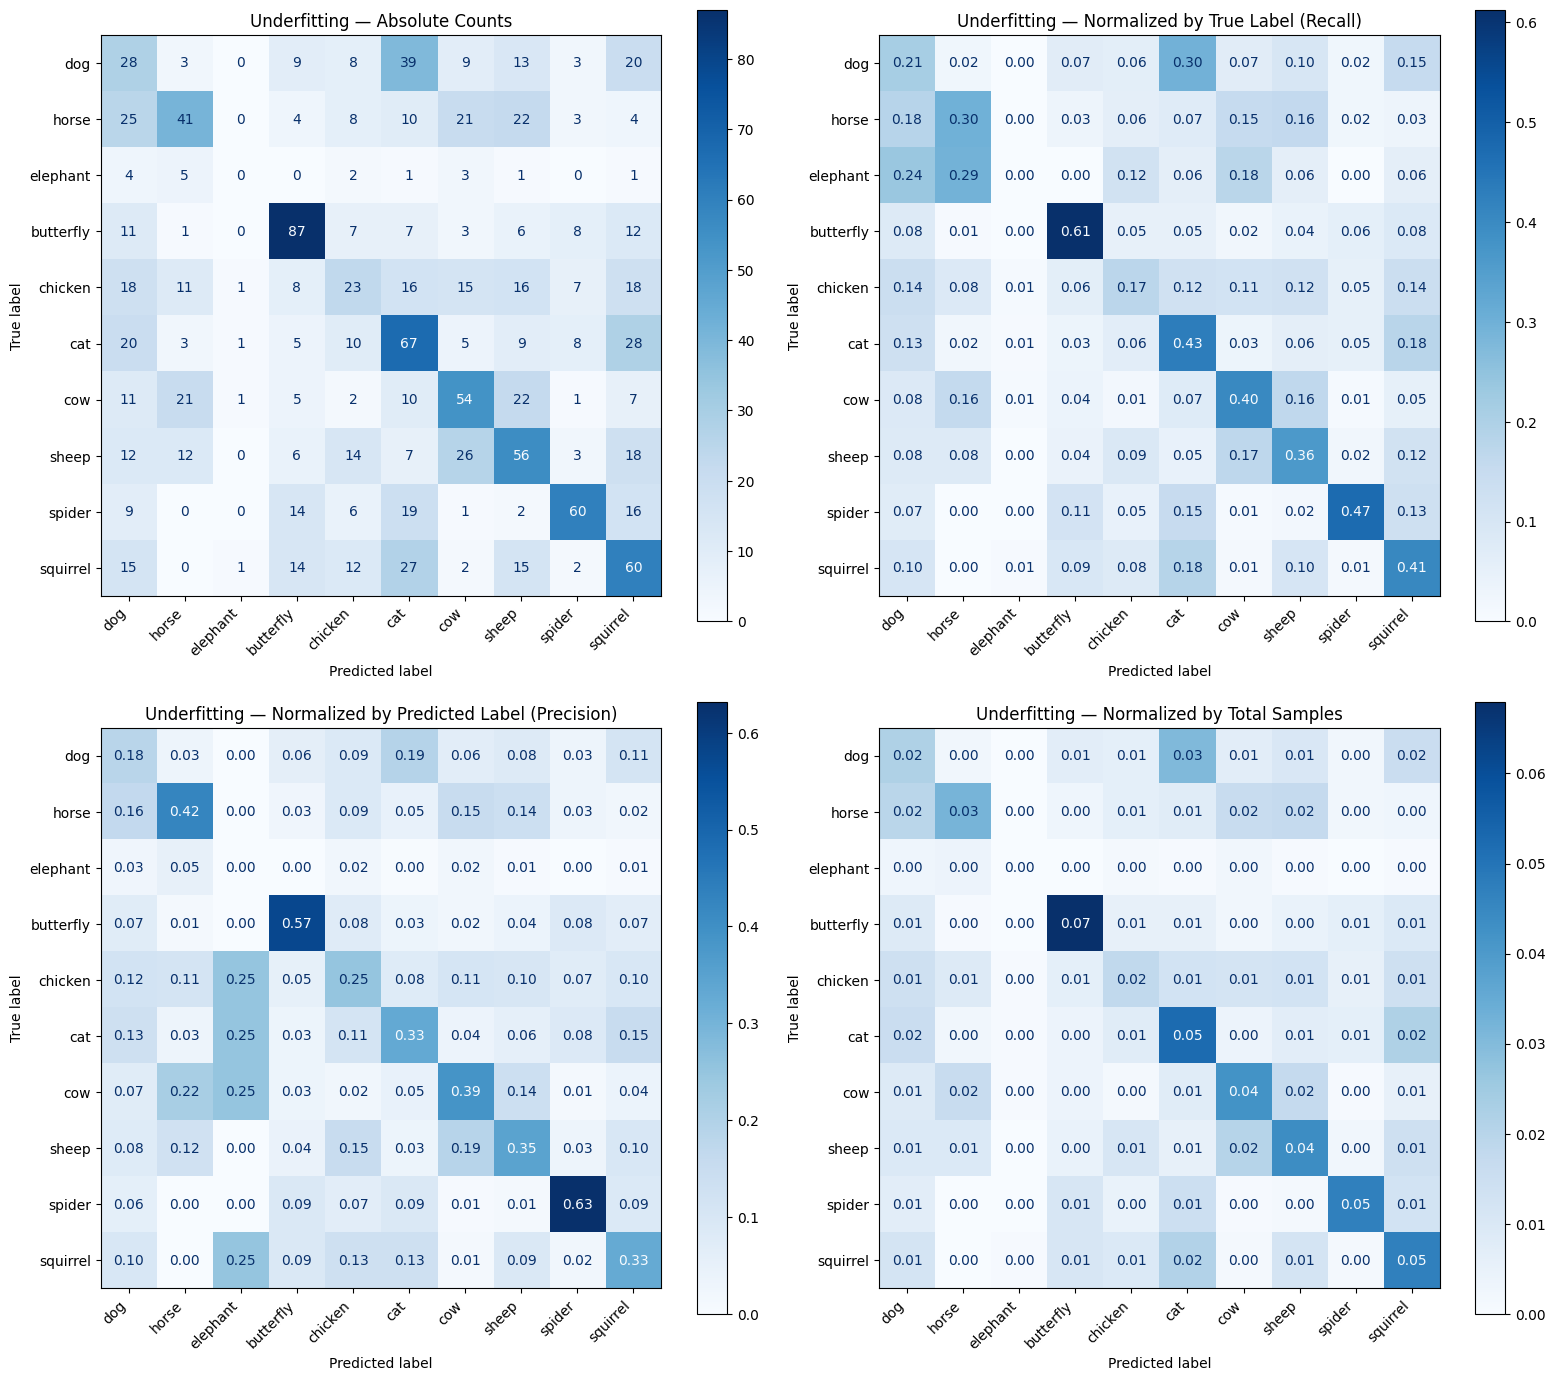

In [12]:
plot_confusion_matrices(y_val, y_pred, class_names, title_prefix="Underfitting — ")

### What the matrix shows

The diagonal is weak across the board, consistent with the low overall accuracy. Elephant sits at 0 recall, the model never predicts this class. After elephant, chicken and dog have the weakest recalls, both well below 25 %. Dog has very low precision as well, and cat's column also gathers a noticeable share of wrong predictions. This is the classic mammal-cluster confusion that a 1.7k-parameter feature extractor cannot resolve (fur, four legs, similar colour palettes). Cat and dog in particular are visibly confused with each other in both directions.

Butterfly stands out as the cleanest class, with spider second. Their distinct silhouettes (wings, multiple thin legs, high-contrast textures) are the kind of features a very small network can still pick up on.

## 9. Classification Metrics

Precision = TP / (TP + FP). Of everything predicted as class X, how much was actually X.
Recall    = TP / (TP + FN). Of all true X samples, how much did we catch.
F1-score  = harmonic mean of precision and recall.

The `support` column is the number of true samples per class, which is useful for spotting classes whose metrics rest on too few examples. Elephant is the obvious one here.

In [13]:
print_classification_metrics(y_val, y_pred, class_names)

Classification Report:
              precision    recall  f1-score   support

         dog      0.183     0.212     0.196       132
       horse      0.423     0.297     0.349       138
    elephant      0.000     0.000     0.000        17
   butterfly      0.572     0.613     0.592       142
     chicken      0.250     0.173     0.204       133
         cat      0.330     0.429     0.373       156
         cow      0.388     0.403     0.396       134
       sheep      0.346     0.364     0.354       154
      spider      0.632     0.472     0.541       127
    squirrel      0.326     0.405     0.361       148

    accuracy                          0.372      1281
   macro avg      0.345     0.337     0.337      1281
weighted avg      0.376     0.372     0.369      1281



## 10. Discussion

The training and validation curves stay close together throughout training and both plateau around 37 % validation accuracy. That matches the classical high-bias / low-variance pattern: the model is wrong in roughly the same way on both sets, so the gap is small but the overall accuracy stays poor.

With around 1700 parameters and only 4 and 8 filters, the network does not have the capacity to build the hierarchical features needed to tell a dog from a cat, let alone from a cow. Anything more complex than a coarse colour/texture pattern is out of reach.

The imbalanced class is where this hurts the most. Elephant has 150 samples against 1000 for every other class, and the model essentially solves it by never predicting "elephant": precision and recall are both 0. When capacity is scarce, the network spends it on the majority classes where most of the loss reduction happens. The few elephant samples end up scattered across the other classes, mostly into columns that are already over-populated by the network.

The next step is to increase capacity. In notebook 2 we deliberately go too far in the other direction to see the opposite failure mode.